# Bug Classification — Transformer Benchmark (4 datasets)

Compares transformer encoders for Quick-to-Investigate-Bug (QIB) classification across the
**four datasets** `Camel, CloudStack, Geode, HBase` (label `0 = NQIB`, `1 = CQIB`).

- **Section A** — **CodeBERT vs BERT vs RoBERTa vs DeBERTa** on every dataset (confusion matrices, comparison bar charts, F1 heatmap)
- **Section B** — **5-fold cross-validation** with 95% confidence intervals, per dataset
- **Section C** — **Continual (sequential) vs individual** training: fine-tune **one CodeBERT one dataset at a time** in `SEQ_ORDER`, evaluated on every dataset's real test set
- **Section D** — **Learning curves** (test F1 vs training-set size)
- **Section E** — **Significance tests** (paired t-test / Wilcoxon on CV folds)
- **Section F** — **Timing** (training time, inference time, throughput)
- **Section G** — **Confusion tables** (per dataset, per model)

> **Runtime note (A100):** Sections A/B/D train across the model×dataset grid, so they are heavy.
> All speed knobs (epochs, which models/datasets, learning-curve fractions) live in the two config
> cells. Trim `CV_MODELS`, `CV_DATASETS`, `LC_MODELS`, `LC_DATASETS` to shorten runs.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup
Pinned, Colab-friendly versions. `sentencepiece`+`protobuf` are for DeBERTa.

In [ ]:
# Install pinned, Colab-friendly versions. sentencepiece+protobuf are for DeBERTa.
!pip -q install "transformers>=4.40,<5" "datasets>=2.19" "accelerate>=0.30" scikit-learn statsmodels nltk sentencepiece protobuf matplotlib seaborn 2>/dev/null
import nltk
for pkg in ["punkt","punkt_tab","stopwords","wordnet","omw-1.4"]:
    try: nltk.download(pkg, quiet=True)
    except Exception: pass
print("Setup done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 135.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.2 MB/s eta 0:00:00
Setup done.


## Imports & device

In [ ]:
import os, re, time, json, inspect, warnings, numpy as np, pandas as pd
import torch
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "| GPU:", torch.cuda.get_device_name(0) if DEVICE=="cuda" else "none")

Device: cuda | GPU: NVIDIA A100-SXM4-40GB


## Config (edit here)

In [ ]:
# ----------------- CONFIG (edit here) -----------------
SEED        = 42
MAX_LEN     = 512          # bug reports are short; 256 covers nearly all. Set 512 for exact paper parity.
LR          = 2e-5          # paper Table
BATCH       = 128            # faster on T4 w/ fp16; set 16 for exact paper parity.
WEIGHT_DECAY= 0.01
LABEL_SMOOTH= 0.1
MAX_GRAD    = 1.0
SCHEDULER   = "cosine"
# Paper uses 50 epochs as an UPPER BOUND with best-F1 checkpointing. Early stopping
# reproduces that cheaply. Bump EPOCHS to 50 + PATIENCE 5 for exact parity if you have time.
EPOCHS      = 10
PATIENCE    = 2
KFOLDS      = 5
SEQ_ORDER   = ["Camel","CloudStack","Geode","HBase"]   # paper order
USE_DRIVE   = False         # set True to also save results to Google Drive
np.random.seed(SEED); torch.manual_seed(SEED)
MODELS = {
    "CodeBERT": "microsoft/codebert-base",
    "BERT":     "bert-base-uncased",
    "RoBERTa":  "roberta-base",
    "DeBERTa":  "microsoft/deberta-base",      # default v1 (no sentencepiece hiccup); swap to "microsoft/deberta-v3-base" for v3
}
os.makedirs("/content/outputs", exist_ok=True)
os.makedirs("/content/ckpt", exist_ok=True)

### Extra knobs for the heavier sections
These control cost of the cross-product sections. Trim to speed things up.

In [ ]:
# ---- knobs for Section B (CV) and Section D (learning curves) ----
CV_EPOCHS    = 6                      # epochs per CV fold  (Section B)
LC_EPOCHS    = 6                      # epochs per learning-curve point (Section D)
LC_FRACTIONS = [0.25, 0.5, 1.0]       # training-size fractions (Section D)

CV_MODELS    = list(MODELS.keys())    # -> e.g. ["CodeBERT"] to shrink Section B
CV_DATASETS  = list(SEQ_ORDER)        # -> subset of datasets for Section B
LC_MODELS    = list(MODELS.keys())    # -> models for the learning-curve section
LC_DATASETS  = list(SEQ_ORDER)        # -> datasets for the learning-curve section

LABEL_NAMES  = ["NQIB", "CQIB"]       # 0 / 1
print("CV:", CV_MODELS, "x", CV_DATASETS, "| LC:", LC_MODELS, "x", LC_DATASETS)

CV: ['CodeBERT', 'BERT', 'RoBERTa', 'DeBERTa'] x ['Camel', 'CloudStack', 'Geode', 'HBase'] | LC: ['CodeBERT', 'BERT', 'RoBERTa', 'DeBERTa'] x ['Camel', 'CloudStack', 'Geode', 'HBase']


## Smoke test

In [ ]:
# --- SMOKE TEST: run this before training ---
assert torch.cuda.is_available(), "GPU NOT active! Colab: Runtime > Change runtime type > A100/T4 GPU, then Restart. "\
                                   "Kaggle: Settings > Accelerator > GPU."
print("GPU OK:", torch.cuda.get_device_name(0))
print(f"MAX_LEN={MAX_LEN}  BATCH={BATCH}  EPOCHS={EPOCHS}  fp16={DEVICE=='cuda'}")
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv

GPU OK: NVIDIA A100-SXM4-40GB
MAX_LEN=512  BATCH=128  EPOCHS=20  fp16=True
name, memory.total [MiB], memory.used [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB, 6 MiB


## 1. Get the data
Upload the four CSVs to `/content` (or clone your repo there). CSVs must have columns
`text,label` (label 0=NQIB, 1=CQIB). The loader tolerates files with or without a header row.

In [ ]:
DATA_DIR = "/content/drive/MyDrive"
print("CSVs found under", DATA_DIR, ":")
!find /content -iname "*.csv" -maxdepth 2 -print

CSVs found under /content/drive/MyDrive :
find: warning: you have specified the global option -maxdepth after the argument -iname, but global options are not positional, i.e., -maxdepth affects tests specified before it as well as those specified after it.  Please specify global options before other arguments.
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv


In [ ]:
# Map project -> filename. Filenames from the repo README; edit if yours differ.
FILE_MAP = {
    "Camel":      ["Camel_DE - v.02.csv","Camel_DE - v.01.csv","Camel.csv"],
    "CloudStack": ["CloudStack_DE - v.01.csv","CloudStack.csv"],
    "Geode":      ["Geode_DE - v.01.csv","Geode.csv"],
    "HBase":      ["Hbase_DE - v.01.csv","HBase_DE - v.01.csv","Hbase.csv","HBase.csv"],
}
def find_file(cands):
    for root,_,fs in os.walk(DATA_DIR):
        for f in fs:
            if f in cands: return os.path.join(root,f)
    # fuzzy fallback: match by project keyword
    return None
def load_one(path):
    # detect header
    head = pd.read_csv(path, nrows=1, header=None)
    has_header = str(head.iloc[0,0]).strip().lower()=="text"
    df = pd.read_csv(path, header=0 if has_header else None)
    if df.shape[1] < 2: raise ValueError(f"{path}: expected 2 columns")
    df = df.iloc[:, :2]; df.columns = ["text","label"]
    df["text"] = df["text"].astype(str)
    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    df = df.dropna(subset=["label"]); df["label"] = df["label"].astype(int)
    df = df[df["label"].isin([0,1])].reset_index(drop=True)
    return df
proj_dfs = {}
for proj, cands in FILE_MAP.items():
    p = find_file(cands)
    if p is None:
        print(f"[WARN] {proj}: none of {cands} found under {DATA_DIR} — upload it or fix FILE_MAP.")
        continue
    proj_dfs[proj] = load_one(p)
    n=len(proj_dfs[proj]); pos=int(proj_dfs[proj].label.sum())
    print(f"{proj:11s} {n:6d} rows | NQIB={n-pos} CQIB={pos}  ({p})")
assert proj_dfs, "No data loaded. Upload the CSVs to /content and check FILE_MAP."

Camel         9019 rows | NQIB=5863 CQIB=3156  (/content/drive/MyDrive/Camel_DE - v.02.csv)
CloudStack    3399 rows | NQIB=2388 CQIB=1011  (/content/drive/MyDrive/CloudStack_DE - v.01.csv)
Geode         3608 rows | NQIB=2839 CQIB=769  (/content/drive/MyDrive/Geode_DE - v.01.csv)
HBase         9201 rows | NQIB=6144 CQIB=3057  (/content/drive/MyDrive/Hbase_DE - v.01.csv)


## 2. Text preprocessing
Same cleaning pipeline as the original notebook (URL normalization, code-token handling, stopword removal).

In [ ]:
from urllib.parse import unquote, urlparse
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def replace_url(match):
    url = match.group(0)
    try:
        parsed_url = urlparse(url)                 # guard: malformed URLs (e.g. stray brackets) raise ValueError
    except ValueError:
        return 'url'
    domain = parsed_url.netloc.replace('www.', '').replace('.com', '').replace('.org', '').replace('.net', '')
    path = unquote(parsed_url.path)

    tokens = re.split(r'[/@]', path)
    tokens = [t for t in tokens if t and len(t) < 20 and not re.match(r'^[0-9a-f]{16,}$', t, re.IGNORECASE)]

    if '@' in url:
        email_domain = re.findall(r'@<*(.*?)>*$', url)
        if email_domain:
            tokens += email_domain[0].split('.')

    tokens = list(dict.fromkeys(tokens))
    tokens = [re.sub(r'[^a-z]', ' ', token.lower()) for token in tokens if token.isalnum() or token.isalpha()]
    tokens = [token for token in tokens if token]

    return 'url of ' + ' '.join([domain] + tokens)

def preprocess_bug_report(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'https?://[^\s]+', replace_url, text)
    text = re.sub(r'\{\{([^}]+)\}\}', r'\1', text)                                     # {{config.property}} -> config.property
    text = re.sub(r'\b[a-zA-Z_]+\.[a-zA-Z0-9_.]+\b', lambda m: m.group(0).replace('.', ' '), text)
    allowed = set('_().')
    text = ''.join(ch if ch.isalnum() or ch.isspace() or ch in allowed else ' ' for ch in text)
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    tokens = [tok for tok in tokens if tok not in stop_words and (tok.isalpha() or re.match(r'[a-zA-Z_]+\(\)', tok))]
    return ' '.join(tokens)

## 3. Preprocess, balance, split (per dataset)

For every project: preprocess text, **upsample the minority class** to balance, then make a
**stratified 80/10/10 train/val/test** split. The `test` split is the held-out *real test set*
used everywhere below. Results are stored in `data[project][train|val|test] = (texts, labels)`.


In [ ]:
def preprocess_df(df):
    df = df.copy()
    df["text"] = df["text"].apply(preprocess_bug_report)
    df = df[df["text"].str.strip() != ""].reset_index(drop=True)
    return df

def balance_df(df):
    maj = df[df.label == 0]; mino = df[df.label == 1]
    if len(maj) == 0 or len(mino) == 0:
        return df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    if len(mino) < len(maj):
        mino = resample(mino, replace=True, n_samples=len(maj), random_state=SEED)
    elif len(maj) < len(mino):
        maj = resample(maj, replace=True, n_samples=len(mino), random_state=SEED)
    return pd.concat([maj, mino]).sample(frac=1, random_state=SEED).reset_index(drop=True)

data = {}
for proj, raw in proj_dfs.items():
    d = balance_df(preprocess_df(raw))
    tr, tmp = train_test_split(d, test_size=0.20, stratify=d.label, random_state=SEED)
    va, te  = train_test_split(tmp, test_size=0.50, stratify=tmp.label, random_state=SEED)
    data[proj] = {
        "train": (tr.text.tolist(), tr.label.tolist()),
        "val":   (va.text.tolist(), va.label.tolist()),
        "test":  (te.text.tolist(), te.label.tolist()),
    }
    print(f"{proj:11s} train={len(tr):6d}  val={len(va):5d}  test={len(te):5d}  "
          f"(test CQIB={int(sum(te.label))})")

PRESENT = [p for p in SEQ_ORDER if p in data]
print("\nDatasets ready:", PRESENT)

Camel       train=  9380  val= 1173  test= 1173  (test CQIB=586)
CloudStack  train=  3820  val=  478  test=  478  (test CQIB=239)
Geode       train=  4542  val=  568  test=  568  (test CQIB=284)
HBase       train=  9830  val= 1229  test= 1229  (test CQIB=614)

Datasets ready: ['Camel', 'CloudStack', 'Geode', 'HBase']


## 4. Shared training harness

One reusable `run_training(...)` used by every section: dynamic padding for speed, best-F1 early
stopping (Section A / C), fp16 on GPU, and metrics via scikit-learn. Models are freed after each run
to keep GPU memory flat. A version shim picks `eval_strategy` vs `evaluation_strategy` automatically.


In [ ]:
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from torch.utils.data import Dataset as TorchDataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback)

_TA_PARAMS = set(inspect.signature(TrainingArguments.__init__).parameters)
EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"

def set_seed(seed=SEED):
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

class BugReportDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings; self.labels = list(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: self.encodings[k][idx] for k in self.encodings}
        item["labels"] = int(self.labels[idx]); return item

def make_dataset(tokenizer, texts, labels):
    enc = tokenizer(list(texts), truncation=True, max_length=MAX_LEN)   # collator pads per batch
    return BugReportDataset(enc, labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple): logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    p, r, f, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": accuracy_score(labels, preds), "f1": f, "precision": p, "recall": r}

def score(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred), "f1": f, "precision": p, "recall": r}

def _labels(predictions):
    if isinstance(predictions, tuple): predictions = predictions[0]
    return np.argmax(predictions, axis=-1)

def build_args(output_dir, epochs, do_eval=True, early_stop=True):
    strat = "epoch" if do_eval else "no"
    kw = dict(
        output_dir=output_dir,
        learning_rate=LR,
        per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=BATCH,
        num_train_epochs=epochs,
        weight_decay=WEIGHT_DECAY,
        label_smoothing_factor=LABEL_SMOOTH,
        max_grad_norm=MAX_GRAD,
        lr_scheduler_type=SCHEDULER,
        warmup_ratio=0.06,
        logging_steps=50,
        fp16=(DEVICE == "cuda"),
        dataloader_num_workers=2,
        save_total_limit=1,
        report_to="none",
        overwrite_output_dir=True,
        load_best_model_at_end=(do_eval and early_stop),
        metric_for_best_model="f1",
        greater_is_better=True,
        save_strategy=("epoch" if (do_eval and early_stop) else "no"),
    )
    kw[EVAL_KEY] = strat
    kw = {k: v for k, v in kw.items() if k in _TA_PARAMS}
    return TrainingArguments(**kw)

def free(*objs):
    for o in objs:
        try: del o
        except Exception: pass
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def run_training(model_ckpt, tr_texts, tr_labels, va_texts, va_labels,
                 eval_texts, eval_labels, epochs=EPOCHS, seed=SEED,
                 tag="run", early_stop=True):
    """Train model on (tr), optionally early-stop on (va), evaluate on (eval_*).
    Returns a lightweight dict; the model/trainer are freed before returning."""
    set_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
    model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2)
    tr_ds = make_dataset(tokenizer, tr_texts, tr_labels)
    collator = DataCollatorWithPadding(tokenizer)

    do_eval = bool(early_stop and va_texts is not None)
    va_ds = make_dataset(tokenizer, va_texts, va_labels) if do_eval else None
    callbacks = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)] if do_eval else []

    trainer = Trainer(
        model=model, args=build_args(f"/content/ckpt/{tag}", epochs, do_eval, early_stop),
        train_dataset=tr_ds, eval_dataset=va_ds, data_collator=collator,
        compute_metrics=compute_metrics, callbacks=callbacks,
    )
    t0 = time.time(); trainer.train(); train_time = time.time() - t0

    eval_ds = make_dataset(tokenizer, eval_texts, eval_labels)
    t1 = time.time(); pred = trainer.predict(eval_ds); infer_time = time.time() - t1
    y_pred = _labels(pred.predictions); y_true = np.array(eval_labels)

    res = {
        "metrics": score(y_true, y_pred),
        "y_pred": y_pred, "y_true": y_true,
        "cm": confusion_matrix(y_true, y_pred, labels=[0, 1]),
        "train_time": train_time, "infer_time": infer_time, "n_eval": len(y_true),
    }
    free(model, trainer)
    return res

print("Harness ready. eval-strategy key:", EVAL_KEY)

Harness ready. eval-strategy key: eval_strategy


# Section A — CodeBERT vs BERT vs RoBERTa vs DeBERTa

For every dataset, train all four models (best-F1 early stopping on the val split) and evaluate on
that dataset's **test set**. `results_A[dataset][model]` holds metrics, confusion matrix, and timing
(reused by Sections C, F, G).


In [ ]:
results_A = {}
for proj in PRESENT:
    results_A[proj] = {}
    tr, va, te = data[proj]["train"], data[proj]["val"], data[proj]["test"]
    print(f"\n########## DATASET: {proj} ##########")
    for name, ckpt in MODELS.items():
        print(f"  -> {name}")
        res = run_training(ckpt, tr[0], tr[1], va[0], va[1], te[0], te[1],
                           epochs=EPOCHS, tag=f"A_{proj}_{name}", early_stop=True)
        results_A[proj][name] = res
        m = res["metrics"]
        print(f"     acc={m['accuracy']:.4f} f1={m['f1']:.4f} prec={m['precision']:.4f} "
              f"rec={m['recall']:.4f}  ({res['train_time']:.0f}s)")

rowsA = [{"dataset": proj, "model": name, **results_A[proj][name]["metrics"]}
         for proj in PRESENT for name in MODELS]
summary_A = pd.DataFrame(rowsA).set_index(["dataset", "model"])
summary_A.round(4)


########## DATASET: Camel ##########
  -> CodeBERT


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

RuntimeError: value cannot be converted to type c10::Half without overflow

In [ ]:
# ============================================================
# RESUME CELL — paste directly BELOW the Section A cell that crashed.
# Fix: DeBERTa overflows in fp16 -> train it in bf16 (A100) with deberta-v3-base.
# Trains ONLY the (dataset, model) pairs still missing from results_A, so the
# hours already spent (Camel CodeBERT/BERT/RoBERTa) are kept. Safe to re-run.
# ============================================================

# 1) Switch DeBERTa to v3 (better on A100) and make sure results_A survives
MODELS["DeBERTa"] = "microsoft/deberta-v3-base"
try:
    results_A
except NameError:
    results_A = {}

DEBERTA_BATCH = 32   # deberta-v3 + relative attention is heavier; keep batch modest to avoid OOM at MAX_LEN=512

# 2) bf16 training-args builder (bf16 has fp32 exponent range -> no Half overflow)
def build_args_bf16(output_dir, epochs, do_eval=True, early_stop=True, batch=BATCH):
    strat = "epoch" if do_eval else "no"
    kw = dict(
        output_dir=output_dir, learning_rate=LR,
        per_device_train_batch_size=batch, per_device_eval_batch_size=batch,
        num_train_epochs=epochs, weight_decay=WEIGHT_DECAY,
        label_smoothing_factor=LABEL_SMOOTH, max_grad_norm=MAX_GRAD,
        lr_scheduler_type=SCHEDULER, warmup_ratio=0.06, logging_steps=50,
        bf16=(DEVICE == "cuda"), fp16=False,          # <-- the fix
        dataloader_num_workers=2, save_total_limit=1, report_to="none",
        overwrite_output_dir=True,
        load_best_model_at_end=(do_eval and early_stop),
        metric_for_best_model="f1", greater_is_better=True,
        save_strategy=("epoch" if (do_eval and early_stop) else "no"),
    )
    kw[EVAL_KEY] = strat
    kw = {k: v for k, v in kw.items() if k in _TA_PARAMS}
    return TrainingArguments(**kw)

# 3) bf16 twin of run_training (same return shape)
def run_training_bf16(model_ckpt, tr_texts, tr_labels, va_texts, va_labels,
                      eval_texts, eval_labels, epochs=EPOCHS, seed=SEED,
                      tag="run", early_stop=True, batch=BATCH):
    set_seed(seed)
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(model_ckpt, use_fast=False)  # deberta-v3 spm fallback
    model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2)
    tr_ds = make_dataset(tokenizer, tr_texts, tr_labels)
    collator = DataCollatorWithPadding(tokenizer)
    do_eval = bool(early_stop and va_texts is not None)
    va_ds = make_dataset(tokenizer, va_texts, va_labels) if do_eval else None
    callbacks = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)] if do_eval else []
    trainer = Trainer(
        model=model, args=build_args_bf16(f"/content/ckpt/{tag}", epochs, do_eval, early_stop, batch),
        train_dataset=tr_ds, eval_dataset=va_ds, data_collator=collator,
        compute_metrics=compute_metrics, callbacks=callbacks,
    )
    t0 = time.time(); trainer.train(); train_time = time.time() - t0
    eval_ds = make_dataset(tokenizer, eval_texts, eval_labels)
    t1 = time.time(); pred = trainer.predict(eval_ds); infer_time = time.time() - t1
    y_pred = _labels(pred.predictions); y_true = np.array(eval_labels)
    res = {"metrics": score(y_true, y_pred), "y_pred": y_pred, "y_true": y_true,
           "cm": confusion_matrix(y_true, y_pred, labels=[0, 1]),
           "train_time": train_time, "infer_time": infer_time, "n_eval": len(y_true)}
    free(model, trainer)
    return res

# 4) Fill in everything still missing (DeBERTa -> bf16; others -> original fp16 run_training)
for proj in PRESENT:
    results_A.setdefault(proj, {})
    tr, va, te = data[proj]["train"], data[proj]["val"], data[proj]["test"]
    for name, ckpt in MODELS.items():
        if name in results_A[proj]:
            print(f"skip {proj}/{name} (already trained)")
            continue
        print(f"\n-> training {proj}/{name}")
        if name == "DeBERTa":
            res = run_training_bf16(ckpt, tr[0], tr[1], va[0], va[1], te[0], te[1],
                                    epochs=EPOCHS, tag=f"A_{proj}_{name}",
                                    early_stop=True, batch=DEBERTA_BATCH)
        else:
            res = run_training(ckpt, tr[0], tr[1], va[0], va[1], te[0], te[1],
                               epochs=EPOCHS, tag=f"A_{proj}_{name}", early_stop=True)
        results_A[proj][name] = res
        m = res["metrics"]
        print(f"   {name}: acc={m['accuracy']:.4f} f1={m['f1']:.4f} "
              f"prec={m['precision']:.4f} rec={m['recall']:.4f} ({res['train_time']:.0f}s)")

print("\nComplete:", {p: list(results_A[p].keys()) for p in results_A})

skip Camel/CodeBERT (already trained)
skip Camel/BERT (already trained)
skip Camel/RoBERTa (already trained)

-> training Camel/DeBERTa


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.693900,0.690923,0.526002,0.407492,0.627846,0.526002
2,0.649000,0.652754,0.640239,0.635518,0.648033,0.640239
3,0.592600,0.618062,0.676897,0.671117,0.690108,0.676897
4,0.523900,0.667347,0.661552,0.629797,0.745397,0.661552
5,0.431600,0.606680,0.724638,0.717097,0.751219,0.724638
6,0.390800,0.657414,0.708440,0.696515,0.747020,0.708440
7,0.349000,0.739745,0.708440,0.697758,0.742488,0.708440


   DeBERTa: acc=0.7323 f1=0.7242 prec=0.7636 rec=0.7323 (781s)

-> training CloudStack/CodeBERT


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.695100,0.684937,0.566314,0.513319,0.616926,0.566314
2,0.676000,0.647032,0.637917,0.633593,0.644631,0.637917
3,0.641300,0.615364,0.681041,0.677841,0.688419,0.681041
4,0.569700,0.574931,0.735557,0.734659,0.738720,0.735557
5,0.510300,0.552195,0.759967,0.759284,0.762889,0.759967
6,0.444800,0.595527,0.745321,0.740019,0.766920,0.745321
7,0.428400,0.567561,0.780309,0.779164,0.786153,0.780309
8,0.367200,0.567175,0.783564,0.782677,0.788186,0.783564
9,0.365300,0.580373,0.785191,0.783859,0.792300,0.785191
10,0.352500,0.575835,0.786819,0.785757,0.792525,0.786819


   RoBERTa: acc=0.7697 f1=0.7688 prec=0.7741 rec=0.7697 (344s)

-> training HBase/DeBERTa


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.689700,0.678305,0.584215,0.575256,0.592127,0.584215
2,0.668000,0.637099,0.655818,0.647252,0.672394,0.655818
3,0.619600,0.628414,0.670464,0.648452,0.727045,0.670464
4,0.531800,0.612427,0.705452,0.693923,0.741627,0.705452
5,0.465900,0.567761,0.769731,0.768612,0.774968,0.769731
6,0.385900,0.609962,0.755899,0.751979,0.773002,0.755899
7,0.351200,0.582051,0.786819,0.786074,0.790791,0.786819
8,0.318900,0.617756,0.790887,0.789917,0.796270,0.790887
9,0.286600,0.642829,0.786819,0.785266,0.795248,0.786819
10,0.287800,0.658559,0.786005,0.784229,0.795622,0.786005


   DeBERTa: acc=0.7860 f1=0.7847 prec=0.7930 rec=0.7860 (1246s)

Complete: {'Camel': ['CodeBERT', 'BERT', 'RoBERTa', 'DeBERTa'], 'CloudStack': ['CodeBERT', 'BERT', 'RoBERTa', 'DeBERTa'], 'Geode': ['CodeBERT', 'BERT', 'RoBERTa', 'DeBERTa'], 'HBase': ['CodeBERT', 'BERT', 'RoBERTa', 'DeBERTa']}


### A.1 — Test F1 heatmap (models × datasets)

In [ ]:
# Rebuild the Section A summary table from results_A (the original cell crashed before this ran)
rowsA = [{"dataset": proj, "model": name, **results_A[proj][name]["metrics"]}
         for proj in PRESENT for name in MODELS]
summary_A = pd.DataFrame(rowsA).set_index(["dataset", "model"])
summary_A.round(4)

accuracy      f1  precision  recall
dataset    model                                        
Camel      CodeBERT    0.8193  0.8191     0.8206  0.8193
           BERT        0.7971  0.7963     0.8022  0.7971
           RoBERTa     0.8184  0.8181     0.8209  0.8184
           DeBERTa     0.7323  0.7242     0.7636  0.7323
CloudStack CodeBERT    0.7720  0.7719     0.7721  0.7720
           BERT        0.5900  0.5898     0.5901  0.5900
           RoBERTa     0.7824  0.7824     0.7824  0.7824
           DeBERTa     0.8410  0.8405     0.8457  0.8410
Geode      CodeBERT    0.7958  0.7955     0.7976  0.7958
           BERT        0.8433  0.8424     0.8514  0.8433
           RoBERTa     0.8415  0.8414     0.8429  0.8415
           DeBERTa     0.8468  0.8457     0.8575  0.8468
HBase      CodeBERT    0.7486  0.7465     0.7570  0.7486
           BERT        0.7909  0.7904     0.7934  0.7909
           RoBERTa     0.7697  0.7688     0.7741  0.7697
           DeBERTa     0.7860  0.7847     0.7930  0.7860

### A.2 — Grouped metric comparison (per dataset)

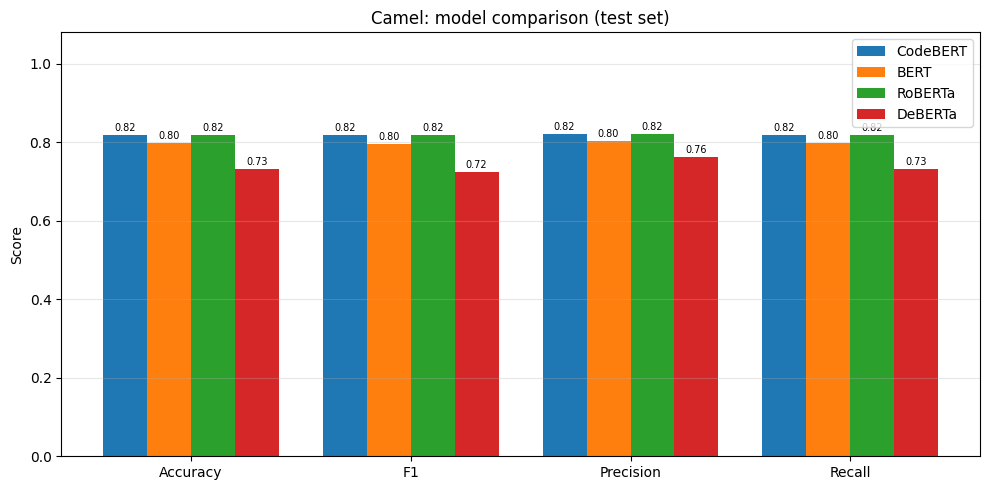

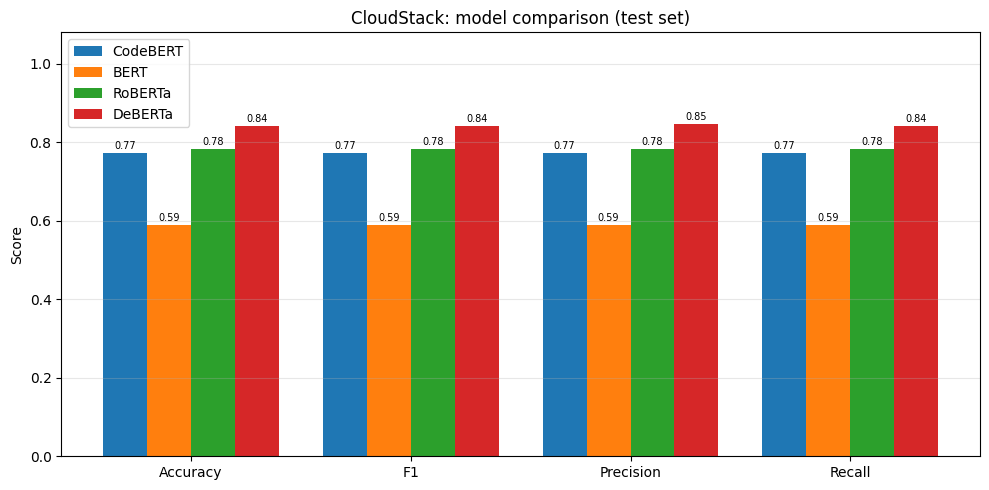

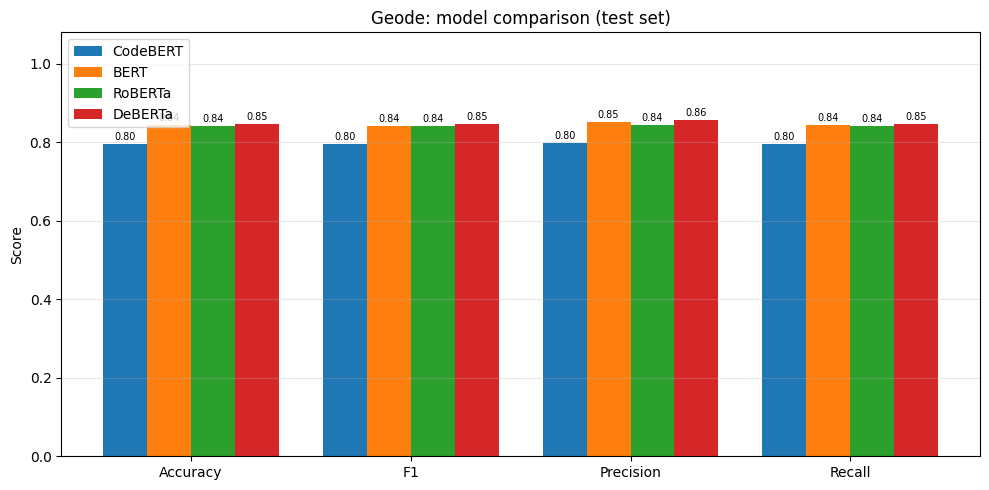

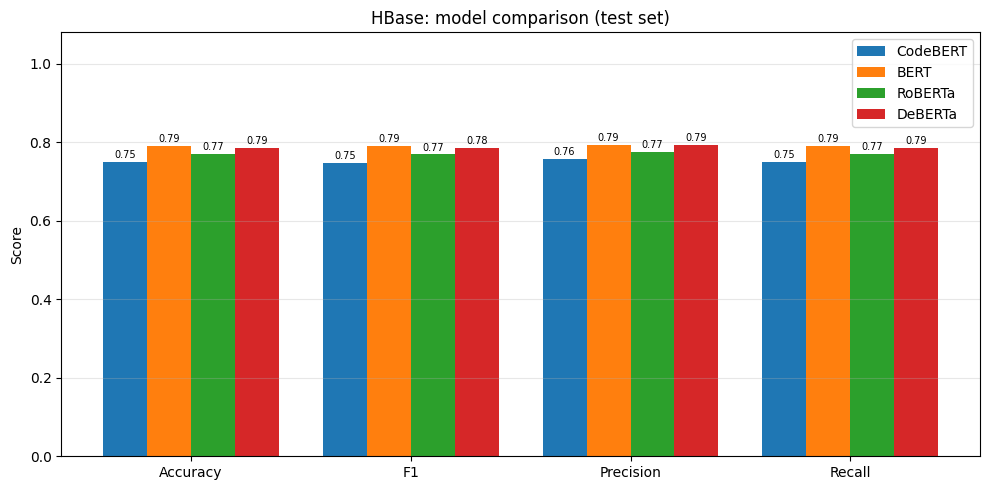

In [ ]:
metrics_order = ["accuracy", "f1", "precision", "recall"]
names = list(MODELS); x = np.arange(len(metrics_order)); w = 0.2
for proj in PRESENT:
    plt.figure(figsize=(10, 5))
    for i, name in enumerate(names):
        vals = [results_A[proj][name]["metrics"][mm] for mm in metrics_order]
        bars = plt.bar(x + (i - (len(names)-1)/2)*w, vals, w, label=name)
        for b, v in zip(bars, vals):
            plt.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.2f}", ha="center", va="bottom", fontsize=7)
    plt.xticks(x, [m.capitalize() for m in metrics_order]); plt.ylim(0, 1.08)
    plt.ylabel("Score"); plt.title(f"{proj}: model comparison (test set)")
    plt.legend(); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

### A.3 — Confusion matrices (per dataset)

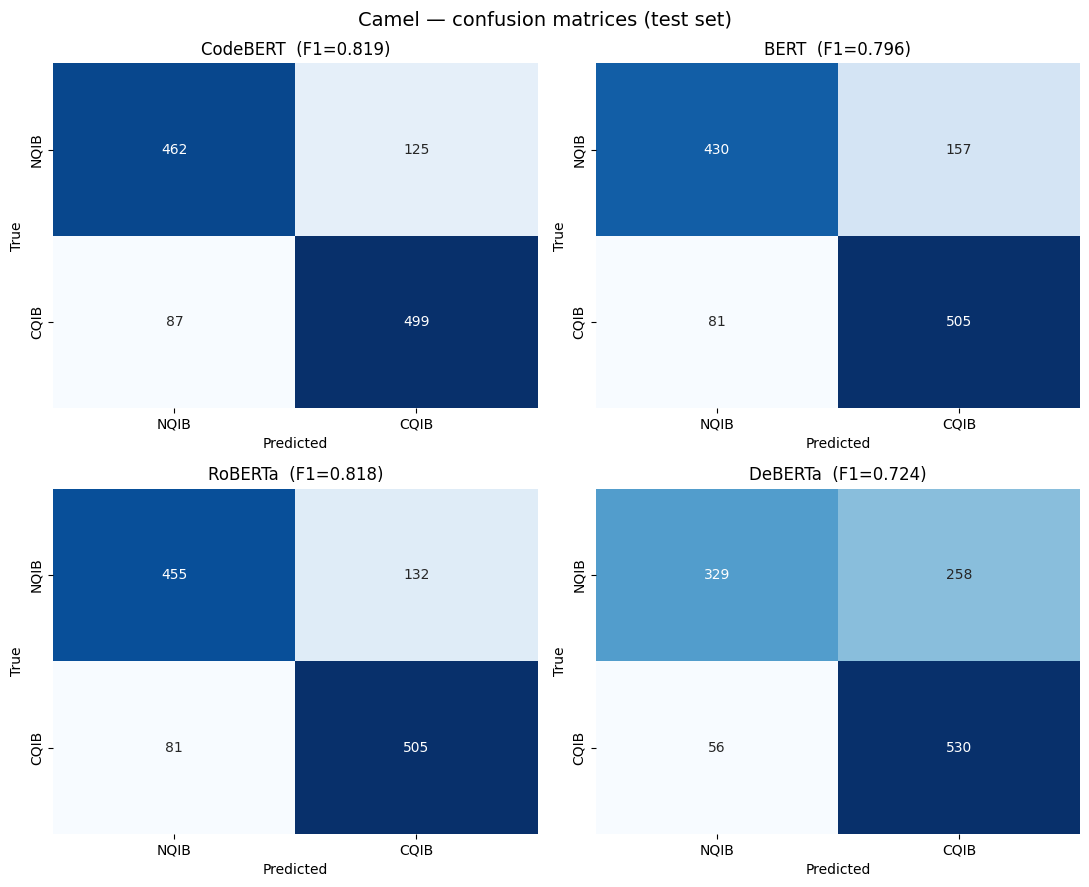

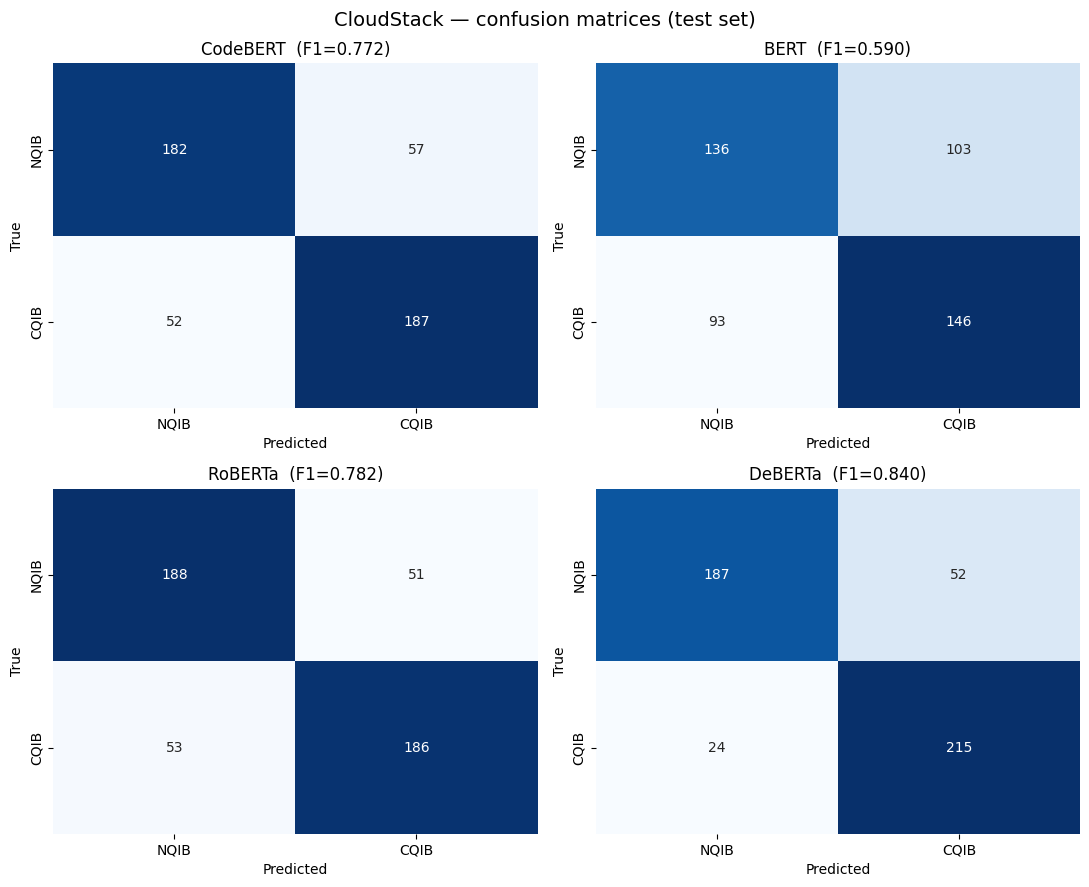

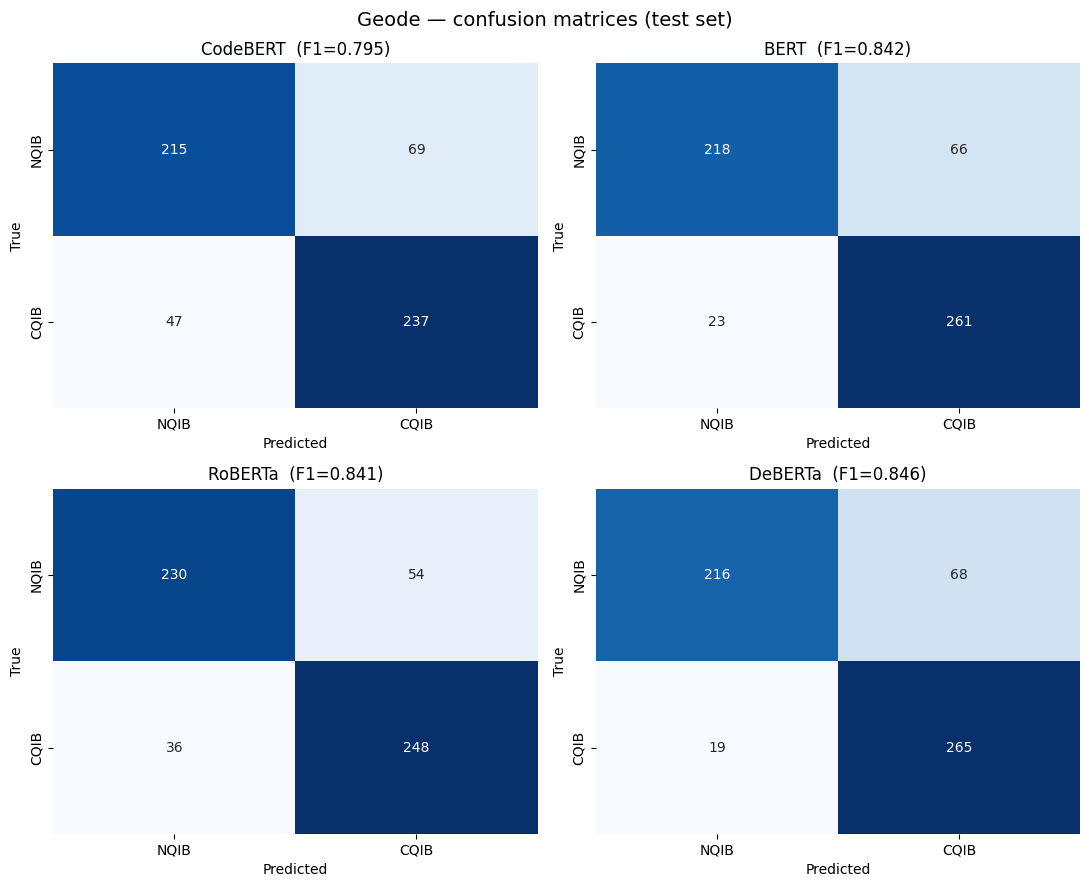

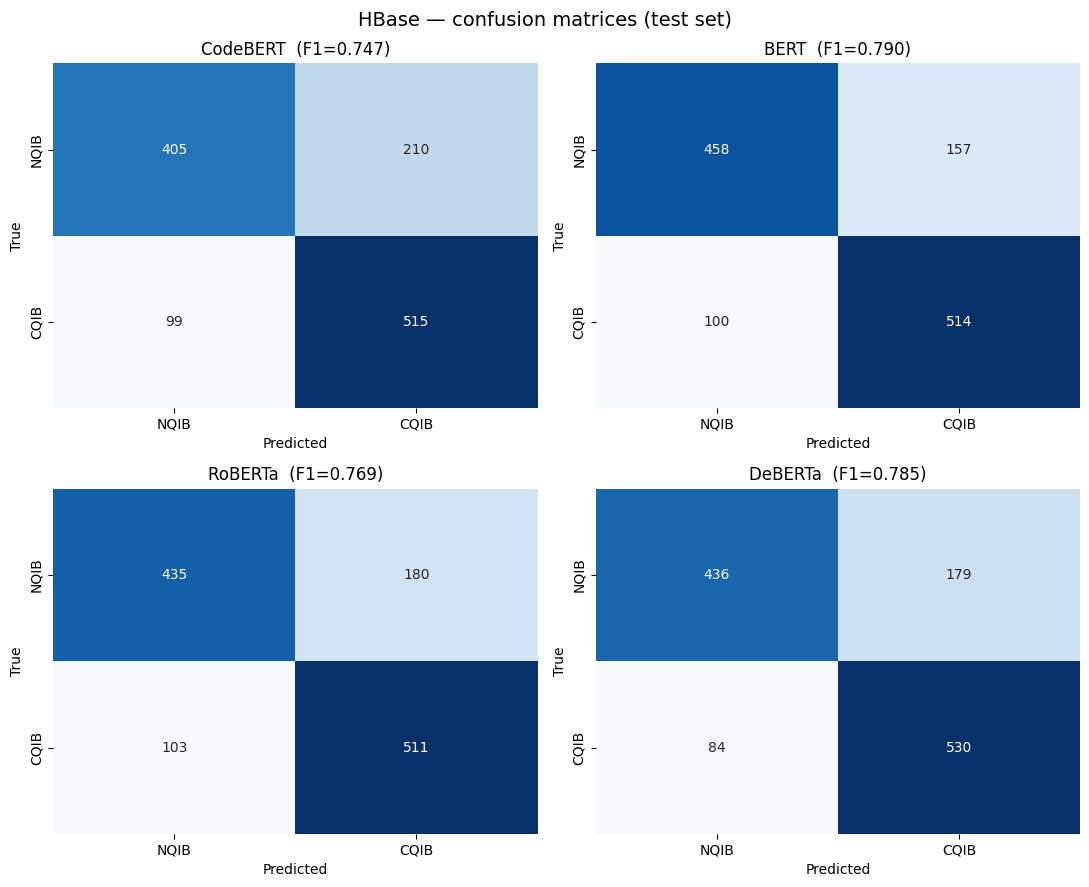

In [ ]:
for proj in PRESENT:
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    for ax, name in zip(axes.ravel(), MODELS):
        res = results_A[proj][name]
        sns.heatmap(res["cm"], annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
        ax.set_title(f"{name}  (F1={res['metrics']['f1']:.3f})")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.suptitle(f"{proj} — confusion matrices (test set)", fontsize=14)
    plt.tight_layout(); plt.show()

# Section B — 5-fold cross-validation with confidence intervals

Stratified `KFOLDS`-fold CV over each dataset's CV pool (train + val; test untouched), for the models
in `CV_MODELS` and datasets in `CV_DATASETS`. Reports mean F1 / accuracy with a **95% CI** (Student-t).
Per-fold F1 scores are kept for the significance tests in Section E.

> Cost = `len(CV_MODELS) * len(CV_DATASETS) * KFOLDS` runs at `CV_EPOCHS`.


In [ ]:
cv_scores = {}
skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)
cv_present = [p for p in CV_DATASETS if p in data]

for proj in cv_present:
    cv_scores[proj] = {}
    tr, va = data[proj]["train"], data[proj]["val"]
    X = np.array(tr[0] + va[0], dtype=object); y = np.array(tr[1] + va[1])
    print(f"\n########## CV DATASET: {proj} ##########")
    for name in CV_MODELS:
        ckpt = MODELS[name]; f1s, accs = [], []
        for fold, (tri, vai) in enumerate(skf.split(X, y)):
            res = run_training(ckpt,
                               X[tri].tolist(), y[tri].tolist(),
                               None, None,                        # no early stopping in CV
                               X[vai].tolist(), y[vai].tolist(),
                               epochs=CV_EPOCHS, seed=SEED + fold,
                               tag=f"B_{proj}_{name}_f{fold}", early_stop=False)
            f1s.append(res["metrics"]["f1"]); accs.append(res["metrics"]["accuracy"])
        cv_scores[proj][name] = {"f1": f1s, "accuracy": accs}
        print(f"  {name:9s} f1={np.mean(f1s):.4f}  acc={np.mean(accs):.4f}")
print("\nDone.")


########## CV DATASET: Camel ##########


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,0.697400
100,0.677900
150,0.646000
200,0.606400
250,0.554500
300,0.526100
350,0.503400


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,0.699200
100,0.685900
150,0.655100
200,0.616300
250,0.570000
300,0.530300
350,0.513100


...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,0.695600
100,0.675500
150,0.643400
200,0.614000
250,0.557800
300,0.532000
350,0.499300


  RoBERTa   f1=0.6690  acc=0.6722


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


OutOfMemoryError: CUDA out of memory. Tried to allocate 768.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 203.44 MiB is free. Including non-PyTorch memory, this process has 39.28 GiB memory in use. Of the allocated memory 38.32 GiB is allocated by PyTorch, and 462.45 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
def mean_ci(vals, conf=0.95):
    v = np.asarray(vals, dtype=float); m = v.mean()
    if len(v) < 2: return m, 0.0
    h = stats.sem(v) * stats.t.ppf((1 + conf) / 2.0, len(v) - 1)
    return m, h

rows = []
for proj in cv_present:
    for name in CV_MODELS:
        f1m, f1h = mean_ci(cv_scores[proj][name]["f1"])
        am, ah   = mean_ci(cv_scores[proj][name]["accuracy"])
        rows.append({"dataset": proj, "model": name,
                     "f1_mean": f1m, "f1_ci95": f1h, "acc_mean": am, "acc_ci95": ah})
cv_summary = pd.DataFrame(rows).set_index(["dataset", "model"])
cv_summary.round(4)

### B.1 — Mean CV F1 with 95% CI (grouped by dataset)

In [ ]:
names = list(CV_MODELS); x = np.arange(len(cv_present)); w = 0.8 / max(len(names), 1)
plt.figure(figsize=(11, 6))
for i, name in enumerate(names):
    means = [mean_ci(cv_scores[p][name]["f1"])[0] for p in cv_present]
    errs  = [mean_ci(cv_scores[p][name]["f1"])[1] for p in cv_present]
    plt.bar(x + (i - (len(names)-1)/2)*w, means, w, yerr=errs, capsize=4, label=name)
plt.xticks(x, cv_present); plt.ylim(0, 1.08); plt.ylabel("F1 (weighted)")
plt.title(f"{KFOLDS}-Fold CV Mean F1 with 95% CI"); plt.legend()
plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

# Section C — Continual (sequential) vs individual training

**CodeBERT**, evaluated on every dataset's real test set.

- **Individual** — a fresh CodeBERT trained per dataset (reused from Section A).
- **Continual / sequential** — start from base CodeBERT and fine-tune it **one dataset at a time**
  in `SEQ_ORDER` (Camel → CloudStack → Geode → HBase), carrying weights forward. After each stage we
  evaluate on **all** datasets' test sets, producing a stage×dataset F1 matrix that reveals forward
  transfer and catastrophic forgetting.


In [ ]:
SEQ_MODEL = "CodeBERT"
present_seq = [p for p in SEQ_ORDER if p in data]

# Individual baseline reused from Section A
individual_f1 = {p: results_A[p][SEQ_MODEL]["metrics"]["f1"] for p in present_seq}

# Continual: one CodeBERT, fine-tuned dataset by dataset
set_seed()
seq_tok = AutoTokenizer.from_pretrained(MODELS[SEQ_MODEL])
seq_model = AutoModelForSequenceClassification.from_pretrained(MODELS[SEQ_MODEL], num_labels=2)
seq_collator = DataCollatorWithPadding(seq_tok)
test_ds_by = {p: make_dataset(seq_tok, *data[p]["test"]) for p in present_seq}

continual_rows = []; seq_train_time = 0.0
for stage, proj in enumerate(present_seq):
    tr, va = data[proj]["train"], data[proj]["val"]
    tr_ds = make_dataset(seq_tok, *tr); va_ds = make_dataset(seq_tok, *va)
    trainer = Trainer(
        model=seq_model,
        args=build_args(f"/content/ckpt/C_seq_{proj}", EPOCHS, do_eval=True, early_stop=True),
        train_dataset=tr_ds, eval_dataset=va_ds, data_collator=seq_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    )
    t0 = time.time(); trainer.train(); seq_train_time += time.time() - t0
    seq_model = trainer.model     # best checkpoint reloaded -> continue from it

    row = {"after": proj}
    for p, ds in test_ds_by.items():
        yp = _labels(trainer.predict(ds).predictions)
        row[p] = score(np.array(data[p]["test"][1]), yp)["f1"]
    continual_rows.append(row)
    print(f"stage {stage+1} (trained {proj}):", {k: round(v,3) for k,v in row.items() if k!='after'})

continual_df = pd.DataFrame(continual_rows).set_index("after")[present_seq]
free(trainer)
continual_df.round(4)

### C.1 — Continual F1 matrix (rows = after training that dataset)

In [ ]:
plt.figure(figsize=(7.5, 6))
sns.heatmap(continual_df, annot=True, fmt=".3f", cmap="viridis", vmin=0, vmax=1,
            cbar_kws={"label": "Test F1"})
plt.title("Continual CodeBERT — test F1 on each dataset after each stage")
plt.xlabel("evaluated on dataset"); plt.ylabel("after training (cumulative)")
plt.tight_layout(); plt.show()

### C.2 — Individual vs continual (final) per dataset

In [ ]:
final_seq = continual_df.iloc[-1]        # after training the last dataset in SEQ_ORDER
x = np.arange(len(present_seq)); w = 0.38
plt.figure(figsize=(10, 5.5))
b1 = plt.bar(x - w/2, [individual_f1[p] for p in present_seq], w, label="Individual", color="#4C72B0")
b2 = plt.bar(x + w/2, [final_seq[p]      for p in present_seq], w, label="Continual (final)", color="#DD8452")
for bars in (b1, b2):
    for b in bars:
        plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f"{b.get_height():.2f}",
                 ha="center", va="bottom", fontsize=8)
plt.xticks(x, present_seq); plt.ylim(0, 1.08); plt.ylabel("Test F1")
plt.title(f"{SEQ_MODEL}: individual vs continual (after full sequence)")
plt.legend(); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

comp_C = pd.DataFrame({"individual_f1": individual_f1,
                       "continual_final_f1": {p: final_seq[p] for p in present_seq}})
comp_C["delta"] = comp_C["continual_final_f1"] - comp_C["individual_f1"]
comp_C.round(4)

# Section D — Learning curves

For each dataset in `LC_DATASETS` and model in `LC_MODELS`, train on increasing fractions
(`LC_FRACTIONS`) of the training set and evaluate on the real test set.

> Cost = `len(LC_DATASETS) * len(LC_MODELS) * len(LC_FRACTIONS)` runs at `LC_EPOCHS`.


In [ ]:
learning_curves = {}
lc_present = [p for p in LC_DATASETS if p in data]
for proj in lc_present:
    learning_curves[proj] = {}
    tr, te = data[proj]["train"], data[proj]["test"]
    print(f"\n########## LEARNING CURVE: {proj} ##########")
    for name in LC_MODELS:
        ckpt = MODELS[name]; sizes, f1s, accs = [], [], []
        for frac in LC_FRACTIONS:
            if frac >= 1.0:
                st, sl = tr[0], tr[1]
            else:
                st, _, sl, _ = train_test_split(tr[0], tr[1], train_size=frac,
                                                stratify=tr[1], random_state=SEED)
            res = run_training(ckpt, st, sl, None, None, te[0], te[1],
                               epochs=LC_EPOCHS, tag=f"D_{proj}_{name}_{int(frac*100)}",
                               early_stop=False)
            sizes.append(len(st)); f1s.append(res["metrics"]["f1"]); accs.append(res["metrics"]["accuracy"])
        learning_curves[proj][name] = {"sizes": sizes, "f1": f1s, "accuracy": accs}
        print(f"  {name:9s} f1@fracs={['%.3f'%v for v in f1s]}")
print("\nDone.")

### D.1 — Learning curves (test F1 vs training size)

In [ ]:
markers = ["o", "s", "^", "D", "v", "P"]
ncol = len(lc_present); fig, axes = plt.subplots(1, ncol, figsize=(6*ncol, 5), squeeze=False)
for ax, proj in zip(axes[0], lc_present):
    for i, name in enumerate(LC_MODELS):
        lc = learning_curves[proj][name]
        ax.plot(lc["sizes"], lc["f1"], marker=markers[i % len(markers)], label=name)
    ax.set_title(proj); ax.set_xlabel("Training samples"); ax.set_ylabel("Test F1")
    ax.grid(alpha=0.3); ax.legend()
plt.suptitle("Learning Curves — Test F1 vs Training-Set Size", fontsize=14)
plt.tight_layout(); plt.show()

# Section E — Significance tests

Using per-fold F1 from Section B, test whether CodeBERT differs significantly from each other model,
per dataset. Folds are shared, so we use **paired** tests: paired t-test and Wilcoxon signed-rank.


In [ ]:
from scipy.stats import ttest_rel, wilcoxon

BASE = "CodeBERT" if "CodeBERT" in CV_MODELS else CV_MODELS[0]
rows = []
for proj in cv_scores:
    base = np.array(cv_scores[proj][BASE]["f1"])
    for name in CV_MODELS:
        if name == BASE: continue
        oth = np.array(cv_scores[proj][name]["f1"])
        t_stat, t_p = ttest_rel(base, oth)
        try:
            _, w_p = wilcoxon(base, oth)
        except ValueError:
            w_p = np.nan
        rows.append({"dataset": proj, "comparison": f"{BASE} vs {name}",
                     "mean_diff_f1": base.mean() - oth.mean(),
                     "t_pvalue": t_p, "wilcoxon_p": w_p, "sig_5pct": bool(t_p < 0.05)})
sig_df = pd.DataFrame(rows).set_index(["dataset", "comparison"])
sig_df.round(4)

### E.1 — Significant wins/losses summary (paired t-test, p < 0.05)

In [ ]:
def verdict(r):
    if r["t_pvalue"] >= 0.05: return "ns"
    return "CodeBERT better" if r["mean_diff_f1"] > 0 else "CodeBERT worse"
sig_view = sig_df.reset_index()
sig_view["verdict"] = sig_view.apply(verdict, axis=1)
sig_view.pivot(index="dataset", columns="comparison", values="verdict")

# Section F — Timing

Training/inference wall-clock and inference throughput (test samples/sec), captured during Section A,
averaged per model across datasets.


In [ ]:
trows = []
for proj in results_A:
    for name in MODELS:
        r = results_A[proj][name]
        trows.append({"dataset": proj, "model": name,
                      "train_s": r["train_time"], "infer_s": r["infer_time"],
                      "throughput": r["n_eval"]/r["infer_time"] if r["infer_time"] > 0 else np.nan})
timing_df = pd.DataFrame(trows)
timing_mean = timing_df.groupby("model")[["train_s", "infer_s", "throughput"]].mean().loc[list(MODELS)]
timing_mean.round(2)

### F.1 — Mean training/inference time & throughput per model

In [ ]:
names = list(MODELS)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, col, title, ylab, color in [
    (axes[0], "train_s",   "Mean Training Time",  "seconds",       "#4C72B0"),
    (axes[1], "infer_s",   "Mean Inference Time", "seconds",       "#55A868"),
    (axes[2], "throughput","Inference Throughput","samples / sec", "#C44E52"),
]:
    vals = [timing_mean.loc[n, col] for n in names]
    bars = ax.bar(names, vals, color=color)
    ax.set_title(title); ax.set_ylabel(ylab); ax.tick_params(axis="x", rotation=30)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
plt.suptitle("Timing (mean across datasets)", fontsize=14)
plt.tight_layout(); plt.show()

# Section G — Confusion tables

Per dataset, per model: confusion matrix as a labeled table plus a per-class report
(precision / recall / F1 / support) on the test set, using Section A predictions.


In [ ]:
from sklearn.metrics import classification_report

def confusion_table(cm):
    return pd.DataFrame(cm, index=[f"true_{l}" for l in LABEL_NAMES],
                        columns=[f"pred_{l}" for l in LABEL_NAMES])

for proj in PRESENT:
    print(f"\n=================== {proj} ===================")
    for name in MODELS:
        res = results_A[proj][name]
        print(f"\n--- {name} ---")
        display(confusion_table(res["cm"]))
        rep = classification_report(res["y_true"], res["y_pred"],
                                    labels=[0, 1], target_names=LABEL_NAMES,
                                    digits=4, output_dict=True, zero_division=0)
        display(pd.DataFrame(rep).T.round(4))

### G.1 — CQIB (critical) F1 across models & datasets

In [ ]:
rows = []
for proj in PRESENT:
    for name in MODELS:
        res = results_A[proj][name]
        rep = classification_report(res["y_true"], res["y_pred"], labels=[0, 1],
                                    target_names=LABEL_NAMES, output_dict=True, zero_division=0)
        rows.append({"dataset": proj, "model": name, "CQIB_f1": rep["CQIB"]["f1-score"]})
cqib = pd.DataFrame(rows).pivot(index="dataset", columns="model", values="CQIB_f1").loc[PRESENT, list(MODELS)]
plt.figure(figsize=(8, 4.8))
sns.heatmap(cqib, annot=True, fmt=".3f", cmap="OrRd", vmin=0, vmax=1)
plt.title("Critical-class (CQIB) F1 — models x datasets"); plt.tight_layout(); plt.show()
cqib.round(4)